Paquetes necesarios

Podremos hacer uso del mismo *environment* de la primera práctica, aunque en ocasiones pedirá instalar Pillow

In [1]:
import cv2  
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

TAREA: Realiza la cuenta de píxeles blancos por filas (en lugar de por columnas). Determina el valor máximo de píxeles blancos para filas, maxfil, mostrando el número de filas y sus respectivas posiciones, con un número de píxeles blancos mayor o igual que 0.90*maxfil. Resalta con alguna primitiva gráfica en la imagen de Canny las filas que cumplen dicha condición.

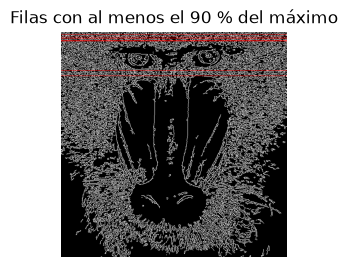

(0.0, 0.47265625000000006)

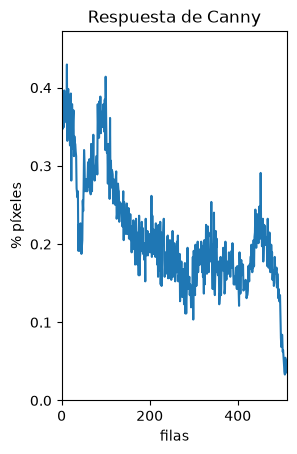

In [2]:

img = cv2.imread('mandril.jpg')
gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
canny = cv2.Canny(gris, 100, 200)
fil_counts = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)   # 0 columnas, 1 filas


filas_cuentas = fil_counts[:, 0] / (255 * canny.shape[1])
maxfil = np.max(filas_cuentas)
umbral = 0.9 * maxfil

filas_selecionadas = np.where(filas_cuentas >= umbral)[0] # Devuelve las filas que cumplen la condición

canny_marcada = cv2.cvtColor(canny, cv2.COLOR_GRAY2BGR) # Convierte a BGR para poder dibujar en color   
    
for fila in filas_selecionadas:
    cv2.line(canny_marcada, (0, fila), (canny.shape[1]-1, fila), (0, 0, 255), 1) 

#Muestra dicha cuenta gráficamente
plt.figure()
plt.subplot(1, 2, 1)
plt.axis("off")
plt.title("Canny")
plt.imshow(canny, cmap='gray') 
plt.imshow(cv2.cvtColor(canny_marcada, cv2.COLOR_BGR2RGB))
plt.title("Filas con al menos el 90 % del máximo")
plt.axis("off")
plt.show()

plt.subplot(1, 2, 2)
plt.title("Respuesta de Canny")
plt.xlabel("filas")
plt.ylabel("% píxeles")
plt.plot(filas_cuentas)
plt.xlim([0, canny.shape[0]])
plt.ylim([0, maxfil * 1.1])

TAREA: Aplica umbralizado a la imagen resultante de Sobel (convertida a 8 bits), y posteriormente realiza el conteo por filas y columnas similar al realizado en el ejemplo con la salida de Canny de píxeles no nulos. Calcula el valor máximo de la cuenta por filas y columnas, y determina las filas y columnas por encima del 0.90*máximo. Remarca con alguna primitiva gráfica dichas filas y columnas sobre la imagen del mandril. Visualiza los resultados obtenidos para la imagen (o una de tu elección) con Canny y Sobe tras umbralizar ¿Cómo se comparan los resultados obtenidos a partir de Sobel y Canny?

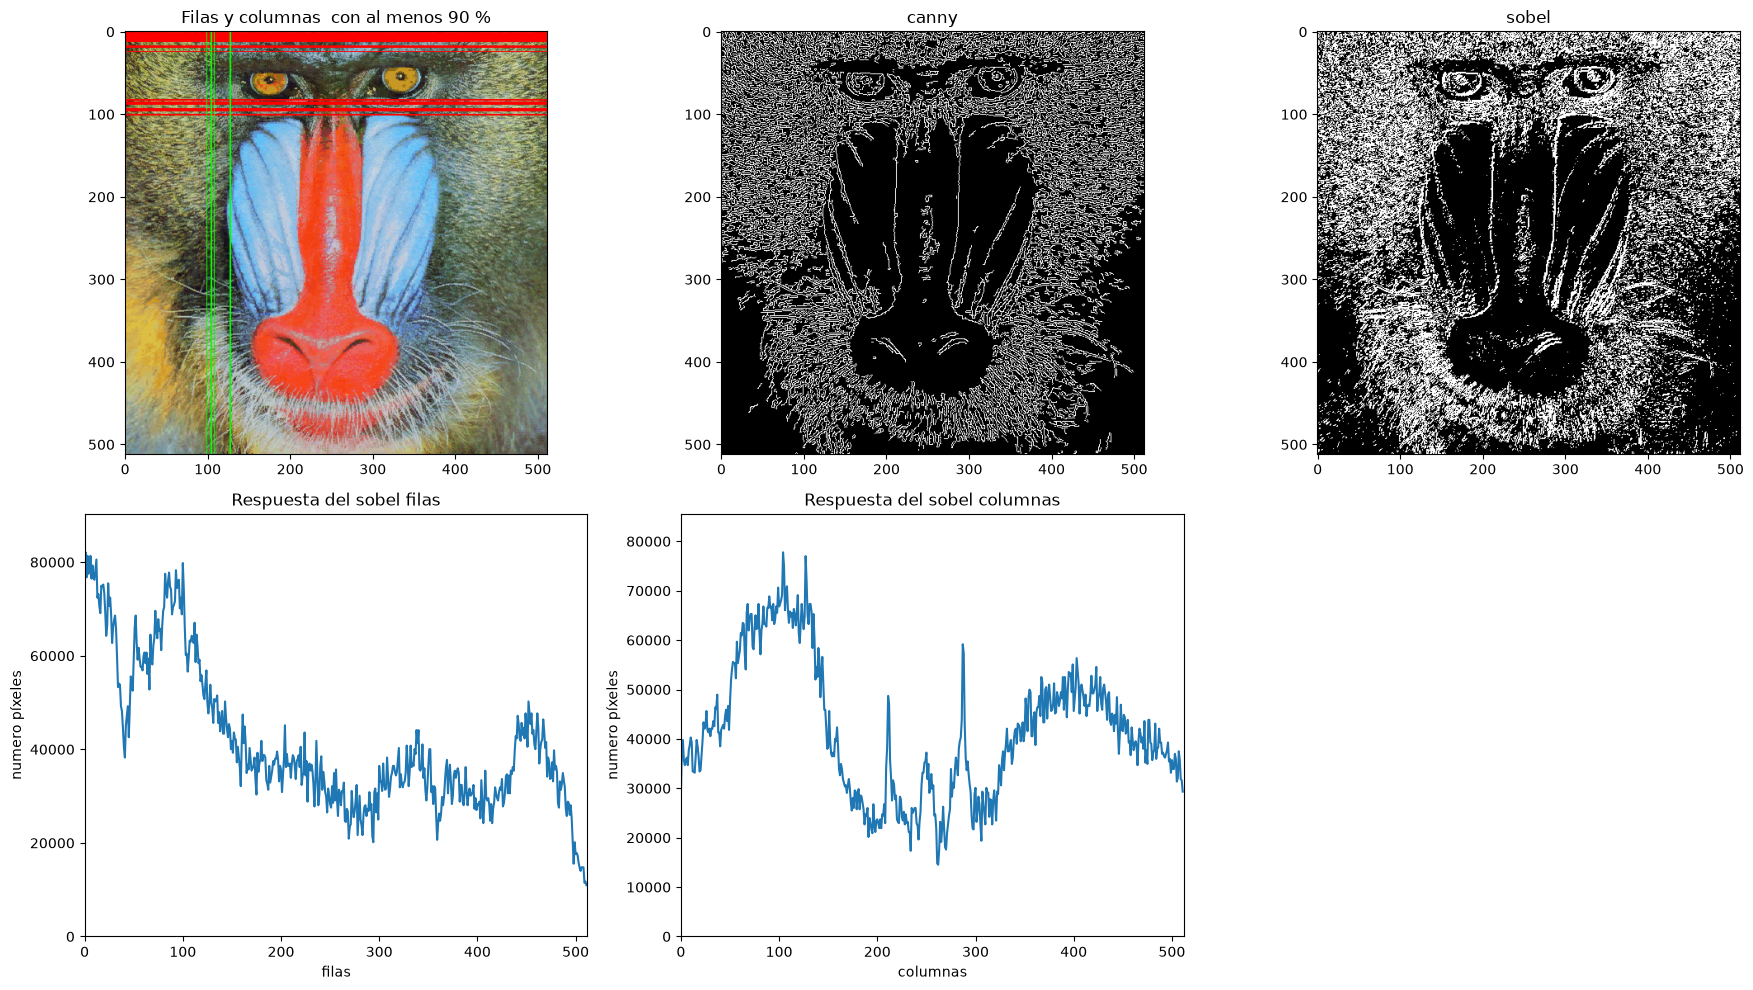

In [6]:
img = cv2.imread('mandril.jpg')
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0)  # x
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1)  # y

sobel = cv2.add(sobelx, sobely)
sobel8 = cv2.convertScaleAbs(sobel)

_, sobel_thresh = cv2.threshold(sobel8, 100, 255, cv2.THRESH_BINARY) 

canny = cv2.Canny(gray, 100, 200)  # Detección de bordes con Canny

conteo_filas = cv2.reduce(sobel_thresh, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)   
conteo_columnas = cv2.reduce(sobel_thresh, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)   

max_filas = np.max(conteo_filas)
max_columnas = np.max(conteo_columnas)

filas_destacadas = np.where(conteo_filas >= 0.9 * max_filas)[0]  # Filas con al menos el 90% del máximo
columnas_destacadas = np.where(conteo_columnas >= 0.9 * max_columnas)[1]  # Columnas con al menos el 90% del máximo
 

for f in filas_destacadas:
    cv2.line(img_rgb, (0, f), (img_rgb.shape[1]-1, f), (255, 0, 0), 1)  # Línea roja para filas
for c in columnas_destacadas:
    cv2.line(img_rgb, (c, 0), (c, img_rgb.shape[0]-1), (0, 255, 0), 1)  # Línea verde para columnas

plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.title("Filas y columnas  con al menos 90 %")
plt.imshow(img_rgb)

plt.subplot(2, 3, 2)
plt.title("canny")
plt.imshow(canny, cmap='gray')

plt.subplot(2, 3, 3)
plt.title("sobel")
plt.imshow(sobel_thresh, cmap='gray')

plt.subplot(2, 3, 4)
plt.title("Respuesta del sobel filas")
plt.xlabel("filas")
plt.ylabel("numero píxeles")
plt.plot(conteo_filas)
plt.xlim([0, sobel_thresh.shape[0]])
plt.ylim([0, max_filas * 1.1])

plt.subplot(2, 3, 5)
plt.title("Respuesta del sobel columnas")
plt.xlabel("columnas")
plt.ylabel("numero píxeles")
plt.plot(conteo_columnas[0])
plt.xlim([0, sobel_thresh.shape[1]])
plt.ylim([0, max_columnas * 1.1])

plt.tight_layout()
plt.show()




TAREA: Tras ver los vídeos [My little piece of privacy](https://www.niklasroy.com/project/88/my-little-piece-of-privacy), [Messa di voce](https://youtu.be/GfoqiyB1ndE?feature=shared) y [Virtual air guitar](https://youtu.be/FIAmyoEpV5c?feature=shared) proponer un demostrador reinterpretando la parte de procesamiento de la imagen, tomando como punto de partida alguna de dichas instalaciones.

In [9]:
video = cv2.VideoCapture(0) 
modo = 1


while True:
        ret, frame = video.read()
        if not ret:
            break
        frame = cv2.flip(frame, 1)  

        tecla = cv2.waitKey(1) & 0xFF
        if tecla == ord('1'):
            modo = 1
        elif tecla == ord('2'):
            modo = 2
        elif tecla == ord('3'):
            modo = 3
        elif tecla == 27:  # Tecla 'ESC' para salir
            break

        # modo 1
        if modo == 1:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            ggris = cv2.GaussianBlur(gray, (5, 5), 0)

            sobelx = cv2.Sobel(ggris, cv2.CV_64F, 1, 0)
            sobely = cv2.Sobel(ggris, cv2.CV_64F, 0, 1)
            sobel = cv2.add(sobelx, sobely)
            sobel8 = cv2.convertScaleAbs(sobel)
            _, sobel_thresh = cv2.threshold(sobel8, 100, 255, cv2.THRESH_BINARY)

            resultado = cv2.cvtColor(sobel_thresh, cv2.COLOR_GRAY2BGR)
            cv2.putText(resultado, "Modo 1: Sobel", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        elif modo == 2:
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            canny = cv2.Canny(gray, 100, 200)

            conteo_filas = cv2.reduce(canny, 1, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)
            conteo_columnas = cv2.reduce(canny, 0, cv2.REDUCE_SUM, dtype=cv2.CV_32SC1)

            max_filas = np.max(conteo_filas)
            max_columnas = np.max(conteo_columnas)

            resultado = frame.copy()

            if max_filas > 0 and max_columnas > 0:
                filas_destacadas = np.where(conteo_filas >= 0.9 * max_filas)[0]
                columnas_destacadas = np.where(conteo_columnas >= 0.9 * max_columnas)[1]

                for f in filas_destacadas:
                    cv2.line(resultado, (0, f), (resultado.shape[1]-1, f), (255, 0, 0), 1)
                for c in columnas_destacadas:
                    cv2.line(resultado, (c, 0), (c, resultado.shape[0]-1), (0, 255, 0), 1)

            cv2.putText(resultado, "Modo 2: Canny", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2) 

        elif modo == 3:
            resultado = np.zeros_like(frame)

            r= frame[:, :, 2]
            g= frame[:, :, 1]
            b = frame[:, :, 0]

            resultado[:, :, 2] = 255- r
            resultado[:, :, 1] = 255- b
            resultado[:, :, 0] =  g

            cv2.putText(resultado, "Modo 3: Color alterado", (10, 30), cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 255, 0), 2)

        cv2.imshow("Instalacion interactiva", resultado)

video.release()
cv2.destroyAllWindows()
